# Dataset Choice and preliminary - Regressions
Task 1 - Task 2
**Dataset:** [Melbourne Housing Snapshot](https://www.kaggle.com/datasets/dansbecker/melbourne-housing-snapshot)
Target: `Price`

In [1]:
import sys, glob, warnings
warnings.filterwarnings("ignore")
sys.path.append("../../") # lets us import helper.py
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display
from helper import *
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

DATA_FILE = glob.glob("../../data/melbourne/*.csv")[0]
TARGET = "Price"
df = pd.read_csv(DATA_FILE)


df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce") # sale date: text - datetime
df["Postcode"] = df["Postcode"].astype("Int64").astype(str) # a code, not a quantity - text
LAT = next(c for c in df.columns if c.lower().startswith("lat"))# the Kaggle file spells it "Lattitude"
LON = next(c for c in df.columns if c.lower().startswith("long"))

num_cols, cat_cols = split_columns(df, TARGET)# feature lists WITHOUT the target (Date is excluded from both)
print(df.shape, "| numeric features:", len(num_cols), "| categorical features:", len(cat_cols))

(13580, 21) | numeric features: 11 | categorical features: 8


## 1a) Datatypes

In [2]:
df.info()
display(column_report(df))
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Suburb         13580 non-null  object        
 1   Address        13580 non-null  object        
 2   Rooms          13580 non-null  int64         
 3   Type           13580 non-null  object        
 4   Price          13580 non-null  float64       
 5   Method         13580 non-null  object        
 6   SellerG        13580 non-null  object        
 7   Date           13580 non-null  datetime64[ns]
 8   Distance       13580 non-null  float64       
 9   Postcode       13580 non-null  object        
 10  Bedroom2       13580 non-null  float64       
 11  Bathroom       13580 non-null  float64       
 12  Car            13518 non-null  float64       
 13  Landsize       13580 non-null  float64       
 14  BuildingArea   7130 non-null   float64       
 15  YearBuilt      8205

,dytpe,missing,missing_%,unique,unique_%,zeros,zeros_%
Suburb,object,0,0.00,314,2.31,NaN,NaN
Address,object,0,0.00,13378,98.51,NaN,NaN
Rooms,int64,0,0.00,9,0.07,0.0,0.00
Type,object,0,0.00,3,0.02,NaN,NaN
Price,float64,0,0.00,2204,16.23,0.0,0.00
Method,object,0,0.00,5,0.04,NaN,NaN
SellerG,object,0,0.00,268,1.97,NaN,NaN
Date,datetime64[ns],0,0.00,58,0.43,NaN,NaN
Distance,float64,0,0.00,202,1.49,6.0,0.04
Postcode,object,0,0.00,198,1.46,NaN,NaN


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,2016-12-03,2.5,3067,2.0,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,2016-02-04,2.5,3067,2.0,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,2017-03-04,2.5,3067,3.0,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,2017-03-04,2.5,3067,3.0,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,2016-06-04,2.5,3067,3.0,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


## 1b) Shapes

Rows: 13580 | Columns: 21
Columns you would get after one-hot encoding every text column: 14218
Rows per raw feature: 679


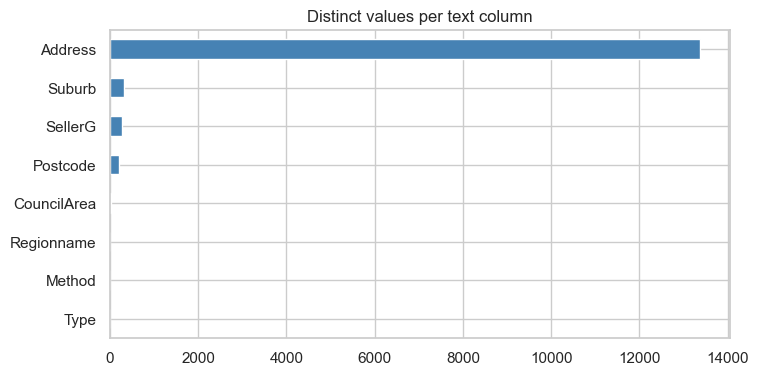

In [3]:
n_rows, n_cols = df.shape
levels = {c: df[c].nunique() for c in cat_cols}
print(f"Rows: {n_rows} | Columns: {n_cols}")
print("Columns you would get after one-hot encoding every text column:", len(num_cols) + sum(levels.values()))
print(f"Rows per raw feature: {n_rows/(n_cols-1):.0f}")
pd.Series(levels).sort_values().plot.barh(figsize=(8, 4), color="steelblue"); plt.title("Distinct values per text column"); plt.show()

## 1c) Missing values, diblicates, zeros, impossible values

,missing,missing_%
BuildingArea,6450,47.50
YearBuilt,5375,39.58
CouncilArea,1369,10.08
Car,62,0.46


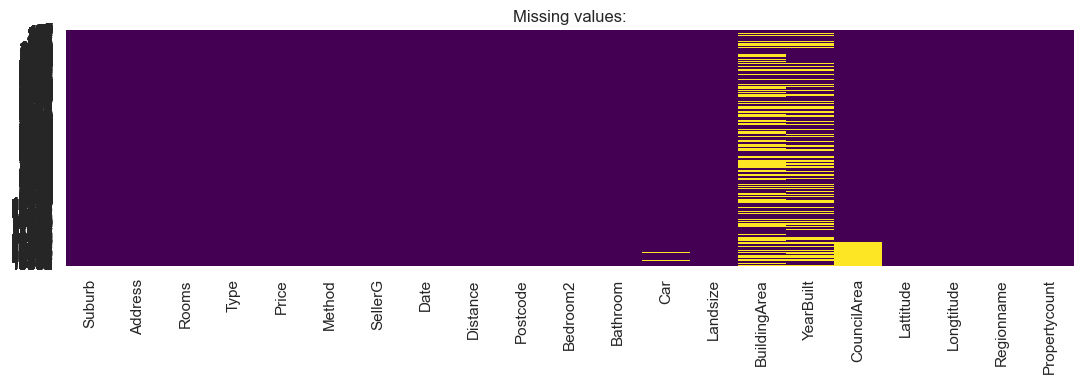

Missing TARGET values: 0
Complete duplicate rows: 0
Same Address + Date duplicated: 5


In [4]:
miss = column_report(df)[["missing", "missing_%"]].sort_values("missing", ascending=False)
display(miss[miss["missing"] > 0])
plot_missing(df)
print("Missing TARGET values:", int(df[TARGET].isna().sum()))
print("Complete duplicate rows:", int(df.duplicated().sum()))
print("Same Address + Date duplicated:", int(df.duplicated(["Address", "Date"]).sum()))

In [5]:
zero_cols = ["Landsize", "BuildingArea", "Bathroom", "Car", "Distance", "Rooms", "Bedroom2"]
display(pd.DataFrame({"zeros": (df[zero_cols] == 0).sum(), "zeros_%": ((df[zero_cols] == 0).mean() * 100).round(2)}))

sale_year = df["Date"].dt.year
checks = pd.Series({
    "Price <= 0": (df[TARGET] <= 0).sum(),
    "Landsize == 0": (df["Landsize"] == 0).sum(),
    "BuildingArea == 0": (df["BuildingArea"] == 0).sum(),
    "Bathroom == 0": (df["Bathroom"] == 0).sum(),
    "Bedroom2 != Rooms": (df["Bedroom2"] != df["Rooms"]).sum(),
    "YearBuilt < 1800": (df["YearBuilt"] < 1800).sum(),
    "YearBuilt after sale year": (df["YearBuilt"] > sale_year).sum(),
    "BuildingArea > Landsize (land > 0)": ((df["BuildingArea"] > df["Landsize"]) & (df["Landsize"] > 0)).sum(),
    "Coordinates outside Melbourne box": (~df[LAT].between(-38.6, -37.2) | ~df[LON].between(144.3, 145.9)).sum(),
    "Date could not be parsed": df["Date"].isna().sum(),
}).to_frame("rows")
display(checks)
print("Sale dates:", df["Date"].min().date(), "->", df["Date"].max().date())
display(df[num_cols].describe().T)

,zeros,zeros_%
Landsize,1939,14.28
BuildingArea,17,0.13
Bathroom,34,0.25
Car,1026,7.56
Distance,6,0.04
Rooms,0,0.00
Bedroom2,16,0.12


,rows
Price <= 0,0
Landsize == 0,1939
BuildingArea == 0,17
Bathroom == 0,34
Bedroom2 != Rooms,676
YearBuilt < 1800,1
YearBuilt after sale year,6
BuildingArea > Landsize (land > 0),262
Coordinates outside Melbourne box,0
Date could not be parsed,0


Sale dates: 2016-01-28 -> 2017-09-23


,count,mean,std,min,25%,50%,75%,max
Rooms,13580.0,2.937997,0.955748,1.00000,2.000000,3.000000,3.000000,10.00000
Distance,13580.0,10.137776,5.868725,0.00000,6.100000,9.200000,13.000000,48.10000
Bedroom2,13580.0,2.914728,0.965921,0.00000,2.000000,3.000000,3.000000,20.00000
Bathroom,13580.0,1.534242,0.691712,0.00000,1.000000,1.000000,2.000000,8.00000
Car,13518.0,1.610075,0.962634,0.00000,1.000000,2.000000,2.000000,10.00000
Landsize,13580.0,558.416127,3990.669241,0.00000,177.000000,440.000000,651.000000,433014.00000
BuildingArea,7130.0,151.967650,541.014538,0.00000,93.000000,126.000000,174.000000,44515.00000
YearBuilt,8205.0,1964.684217,37.273762,1196.00000,1940.000000,1970.000000,1999.000000,2018.00000
Lattitude,13580.0,-37.809203,0.079260,-38.18255,-37.856822,-37.802355,-37.756400,-37.40853
Longtitude,13580.0,144.995216,0.103916,144.43181,144.929600,145.000100,145.058305,145.52635


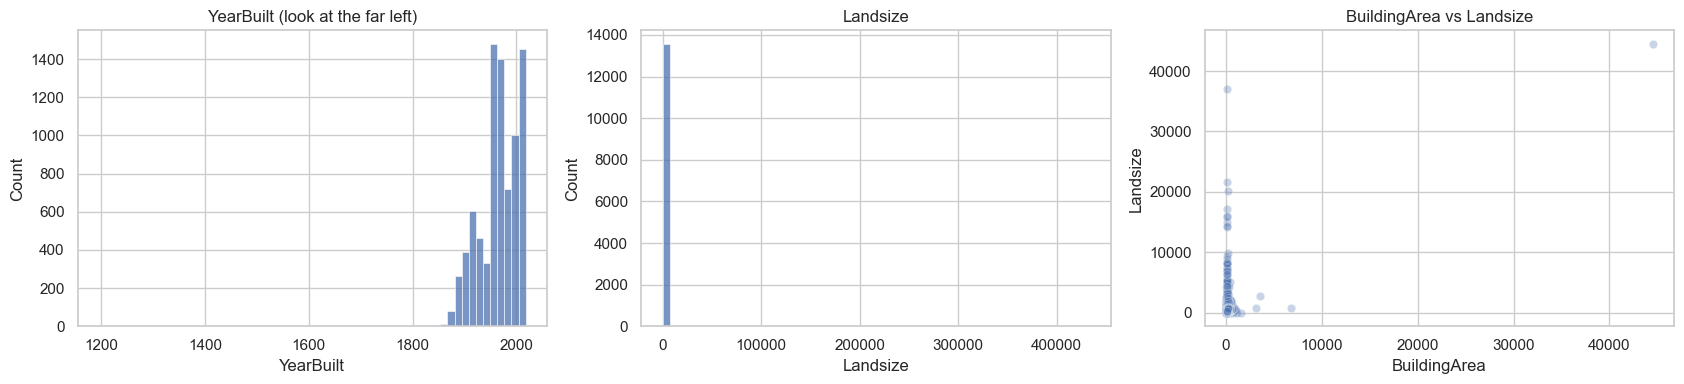

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4))
sns.histplot(df["YearBuilt"].dropna(), bins=60, ax=ax[0]); ax[0].set_title("YearBuilt (look at the far left)")
sns.histplot(df["Landsize"], bins=60, ax=ax[1]); ax[1].set_title("Landsize")
sns.scatterplot(data=df, x="BuildingArea", y="Landsize", alpha=.3, ax=ax[2]); ax[2].set_title("BuildingArea vs Landsize")
plt.tight_layout(); plt.show()

## 1d) Alerts from big-picture tools

In [7]:
import os
os.makedirs("../../reports", exist_ok=True)
try:
    from ydata_profiling import ProfileReport
    profile = ProfileReport(df, title="Melbourne Housing - preliminary EDA", explorative=True)
    profile.to_file("../../reports/melbourne_ydata_profile.html")
    print("Saved reports/melbourne_ydata_profile.html  -> open it in your browser")
    try:
        display(pd.DataFrame({"ydata-profiling alert": [str(a) for a in profile.get_description().alerts]}))
    except Exception as e:
        print("(Could not list alerts here - read the Alerts tab in the HTML.)", e)
except ImportError:
    print("ydata-profiling is not installed.  Run:  pip install ydata-profiling")

ydata-profiling is not installed.  Run:  pip install ydata-profiling


In [8]:
try:
    import sweetviz as sv
    sv.analyze(df.drop(columns=["Address"]), target_feat=TARGET).show_html("../../reports/melbourne_sweetviz.html", open_browser=False)
    print("Saved reports/melbourne_sweetviz.html")
except Exception as e:
    print("SweetViz skipped:", type(e).__name__, "- optional: pip install sweetviz")

SweetViz skipped: ModuleNotFoundError - optional: pip install sweetviz


## personal notes

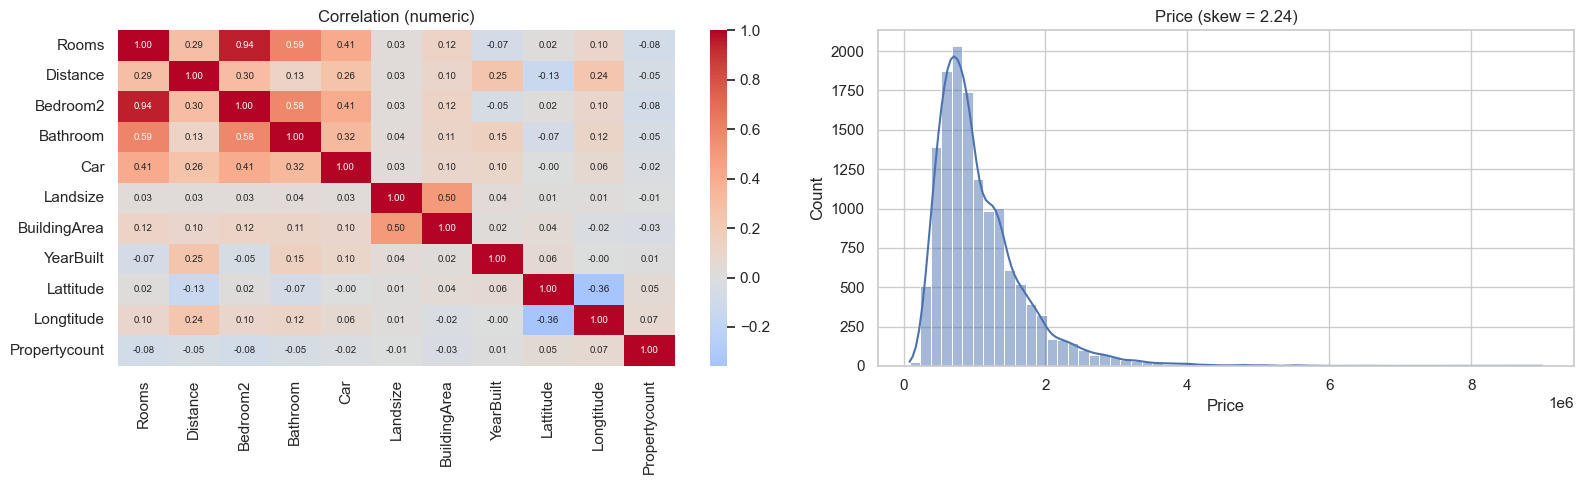

,feature_1,feature_2,abs_corr
0,Rooms,Bedroom2,0.94419


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, annot_kws={"size": 7}, ax=ax[0]); ax[0].set_title("Correlation (numeric)")
sns.histplot(df[TARGET].dropna(), bins=60, kde=True, ax=ax[1]); ax[1].set_title(f"{TARGET} (skew = {df[TARGET].skew():.2f})")
plt.tight_layout(); plt.show()
display(high_corr_pairs(df, num_cols, 0.7))